## This notebook is a feasibility-test of the link budget computations of the balloon-sat project with considerations for base-station size and antenna placement on the balloon.

### 1.0 Free Space Path Loss

for RF in free space, the equation that determines path loss for a link is defined below.

$$PL \text{ (dB)} = 32.45 + 20 \log_{10}(f_{\text{MHz}}) + 20 \log_{10}(d_{\text{km}})$$

Where:
- $PL$ = Path Loss (dB)
- $f_{\text{MHz}}$ = Frequency (MHz)
- $d_{\text{km}}$ = Distance (km)

### 1.1 Path Loss with balloon altitude

Using the Free Space Path Loss Equation defined above, we can graph the change in path loss at a moderate distance to simulate launch rise conditions and also the final point- the high altitude float path loss.


Path loss at 15 km altitude:

145 MHz (2m)         99.20 dB
435 MHz (70cm)       108.74 dB


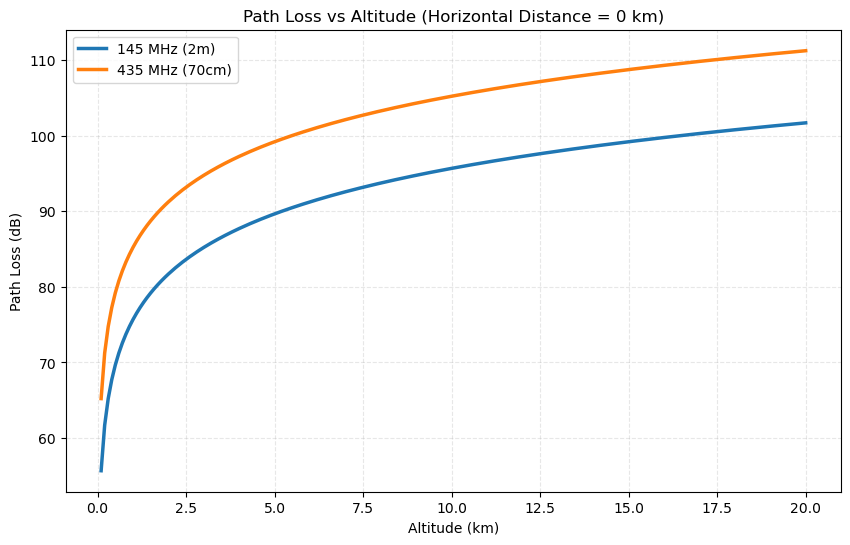

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Free-space path loss
def calculate_path_loss(distance_km, frequency_mhz):
    return 32.45 + 20 * np.log10(frequency_mhz) + 20 * np.log10(distance_km)

# Parameters
horizontal_distance_km = 0  # ground distance from you to balloon
altitude_km = np.linspace(0.1, 20, 200)  # avoid log(0)

frequencies = {
    '145 MHz (2m)': 145,
    '435 MHz (70cm)': 435
}

fig, ax = plt.subplots(figsize=(10, 6))

for label, freq in frequencies.items():
    # Compute slant range
    slant_range = np.sqrt(horizontal_distance_km**2 + altitude_km**2)
    
    # Compute path loss
    path_loss = calculate_path_loss(slant_range, freq)
    
    ax.plot(altitude_km, path_loss, linewidth=2.5, label=label)

ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Path Loss (dB)')
ax.set_title(f'Path Loss vs Altitude (Horizontal Distance = {horizontal_distance_km} km)')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

service_ceiling = 15
slant_15km = np.sqrt(horizontal_distance_km**2 + service_ceiling**2)

print("\nPath loss at 15 km altitude:\n")
for label, freq in frequencies.items():
    loss = calculate_path_loss(slant_15km, freq)
    print(f"{label:20} {loss:.2f} dB")

plt.show()

When holding distance to the balloon constant and assuming perfectly vertical ascent, we see a relationship with both the 2m and 70cm ham radio bands of a very large exponential increase through the initial climb of the path loss with a roughly 35 db increase in path loss throughout the climb up to 20km, which is roughly the service ceiling of a pico balloon class payload.

The link budget should be computed reguarding the service ceiling with the consideration that the balloon during the climb should be not only much easier to hear but also much easier to command with a lower-power base station.


### 1.2 balloon visibility distance

An important note for the balloon is the changing distance covered by the balloon in relation to its altitude, so below it is calculated to estimate a maximum mutual visibility circle covered by the satellite. This will also be used for computing the link budget later to see the maximum distance the balloon could be seen and utilized, and what the distance increase could mean for a stations requirements to utilize the balloon.

#### We model Earth as a sphere with radius \( R_E \), and the satellite at altitude \( h \).

#### Horizon condition

At the horizon point, the line of sight is tangent to Earth:

$$
\cos(\theta) = \frac{R_E}{R_E + h}
$$

Where:

- $\theta$ = central angle from sub-satellite point (radians)

---

#### Ground distance (great-circle arc length)

$$
d = R_E \cdot \theta
$$

Substituting:

$$
d = R_E \cdot \cos^{-1}\left(\frac{R_E}{R_E + h}\right)
$$

---

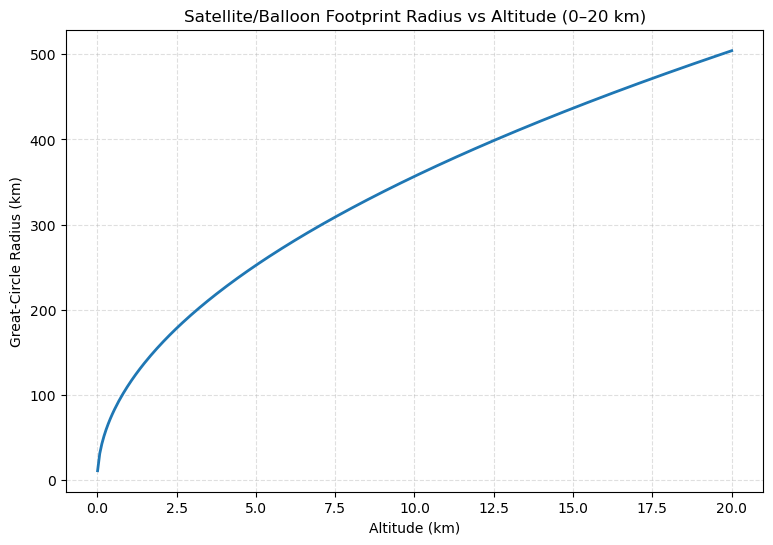

Great-circle footprint at 15 km altitude:

d ≈ 436.76 km


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Earth radius (km)
R_E = 6371.0

# Altitude range (km)
altitude_km = np.linspace(0.01, 20, 300)

# Great-circle footprint radius
def footprint_radius(h):
    theta = np.arccos(R_E / (R_E + h))
    return R_E * theta

radius_km = footprint_radius(altitude_km)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(altitude_km, radius_km, linewidth=2)

ax.set_xlabel("Altitude (km)")
ax.set_ylabel("Great-Circle Radius (km)")
ax.set_title("Satellite/Balloon Footprint Radius vs Altitude (0–20 km)")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

# --- 15 km calculation (no plot marker) ---
h_15 = 15
r_15 = footprint_radius(h_15)

print("Great-circle footprint at 15 km altitude:\n")
print(f"d ≈ {r_15:.2f} km")

With this we can see that roughly the maximum range for a station to get into the balloon will be 436km. This provides an important maximum for a "command distance" as any further and the balloon will be below the horizon and the link margin increases because of absorbtion beyond the horizon. With this radius we can also estimate the maximum distance between two stations using the balloon as a mutual hop would be double this, the greatcircle diameter, which is roughly 880 Km.

### 1.3 Path Loss with balloon horizontal distance


=== Values at 250 km ground distance ===

145 MHz (2m)
  Path Loss @250 km: 123.65 dB
  dPL/dx @250 km:     0.0346 dB/km

435 MHz (70cm)
  Path Loss @250 km: 133.19 dB
  dPL/dx @250 km:     0.0346 dB/km



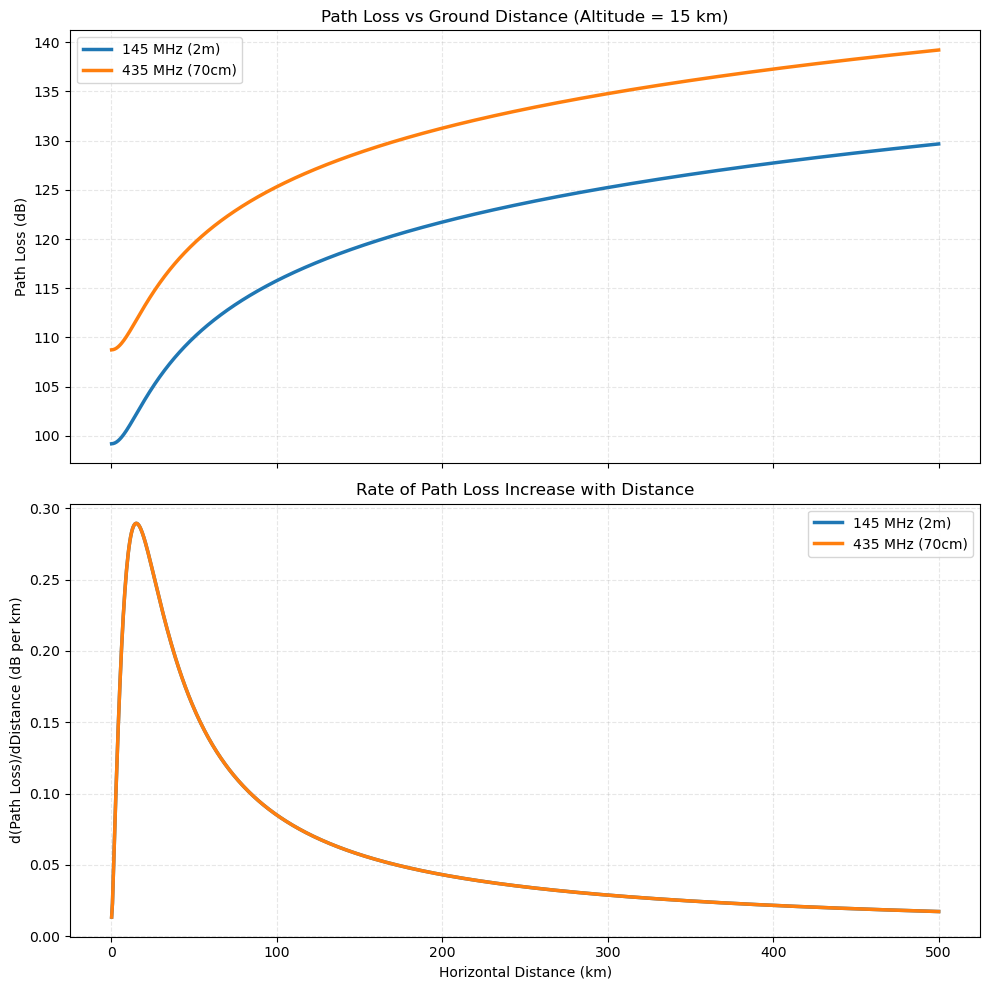

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Free-space path loss
def calculate_path_loss(distance_km, frequency_mhz):
    return 32.45 + 20 * np.log10(frequency_mhz) + 20 * np.log10(distance_km)

# Parameters
altitude_km = 15
horizontal_distance_km = np.linspace(0.1, 500, 1000)

frequencies = {
    '145 MHz (2m)': 145,
    '435 MHz (70cm)': 435
}

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for label, freq in frequencies.items():
    slant_range = np.sqrt(horizontal_distance_km**2 + altitude_km**2)
    path_loss = calculate_path_loss(slant_range, freq)

    # --- Main plot ---
    ax1.plot(horizontal_distance_km, path_loss, linewidth=2.5, label=label)

    # --- Numerical derivative ---
    dPL_dx = np.gradient(path_loss, horizontal_distance_km)
    ax2.plot(horizontal_distance_km, dPL_dx, linewidth=2.5, label=label)

# Styling main plot
ax1.set_ylabel("Path Loss (dB)")
ax1.set_title(f"Path Loss vs Ground Distance (Altitude = {altitude_km} km)")
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.legend()

# Styling derivative plot
ax2.set_xlabel("Horizontal Distance (km)")
ax2.set_ylabel("d(Path Loss)/dDistance (dB per km)")
ax2.set_title("Rate of Path Loss Increase with Distance")
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend()

# --- Sample point ---
test_distance = 250  # km
h = 0.5  # small step for numerical derivative (km)

slant_test = np.sqrt(test_distance**2 + altitude_km**2)

print(f"\n=== Values at {test_distance} km ground distance ===\n")

for label, freq in frequencies.items():
    # Path loss at point
    pl = calculate_path_loss(slant_test, freq)

    # Finite difference derivative (local slope)
    d1 = np.sqrt((test_distance + h)**2 + altitude_km**2)
    d2 = np.sqrt((test_distance - h)**2 + altitude_km**2)

    pl1 = calculate_path_loss(d1, freq)
    pl2 = calculate_path_loss(d2, freq)

    dpl_dx = (pl1 - pl2) / (2 * h)

    print(f"{label}")
    print(f"  Path Loss @250 km: {pl:.2f} dB")
    print(f"  dPL/dx @250 km:     {dpl_dx:.4f} dB/km\n")
    
plt.tight_layout()
plt.show()

It is also important to note that the pico-balloon class of payload weight and balloon size have velocities at 15km of 100-270Km/Hr, which then becomes an estimate of 1.6-4.5 km/minute. This then would become a change in roughly 0.05536-0.1557db/minute at 250km of horizontal distance, which is far under an S unit a minute, and a change of 3.46-9.42db/Hr which would mean that over the course of an hour the link would significantly change, and this is worth noting for later mission objectives such a crossband repeater onboard and how long it should be active. This change would represent roughly the change from halfway out of the great circle to either the edge or directly overhead.

### 2.0 Transciever Requirements

We can break up the link budget portion of the station requirements to utilize the balloon into two segments, the Uplink and the Downlink.

The Uplink we will consider transmitter power, station antenna, recieving antenna on the balloon and the recieving performance of the planned DRA818.

The Downlink we will consider the DRA818's transmit power with both potential bands and antennas, and then recieving performance of an average FM transciever with an average recieving antenna.

### 2.1 Uplink Requirements

For the Uplink, a few parameters we will be using:

#### Transmitter Power : 37dBm (5W) - Average HT
#### Transmit Antenna  : 0 dBi - Quarter Wave Whip antenna

#### Recieving Antenna : ~ 0 dBi Quarter Wave Whip on Balloon for 2m
#### Recieving Antenna : ~ 2.5 dBi Dipole on Balloon on 70cm
#### DRA818 Recieving Performance : ~ -120dbm noise floor

10 dB of polarization loss is estimated for the balloons uncontrolled tumble.

#### Path Loss
We will be using the estimate of 250km of horizontal distance and 15km of vertical altitude to assume the most average station location case in reference to the balloon

2m Path Loss : 123.64dB

70cm Path Loss : 133.1dB

#### Mode-Specific SNR Requirements
These estimates are rough based on links for satellites for SNR needed for a positive packet decode and a good signal for FM voice.

FM Voice : 15dB SNR for readable voice

1200 Baud APRS Packet Deocde : 10dB SNR for consistency in decoding

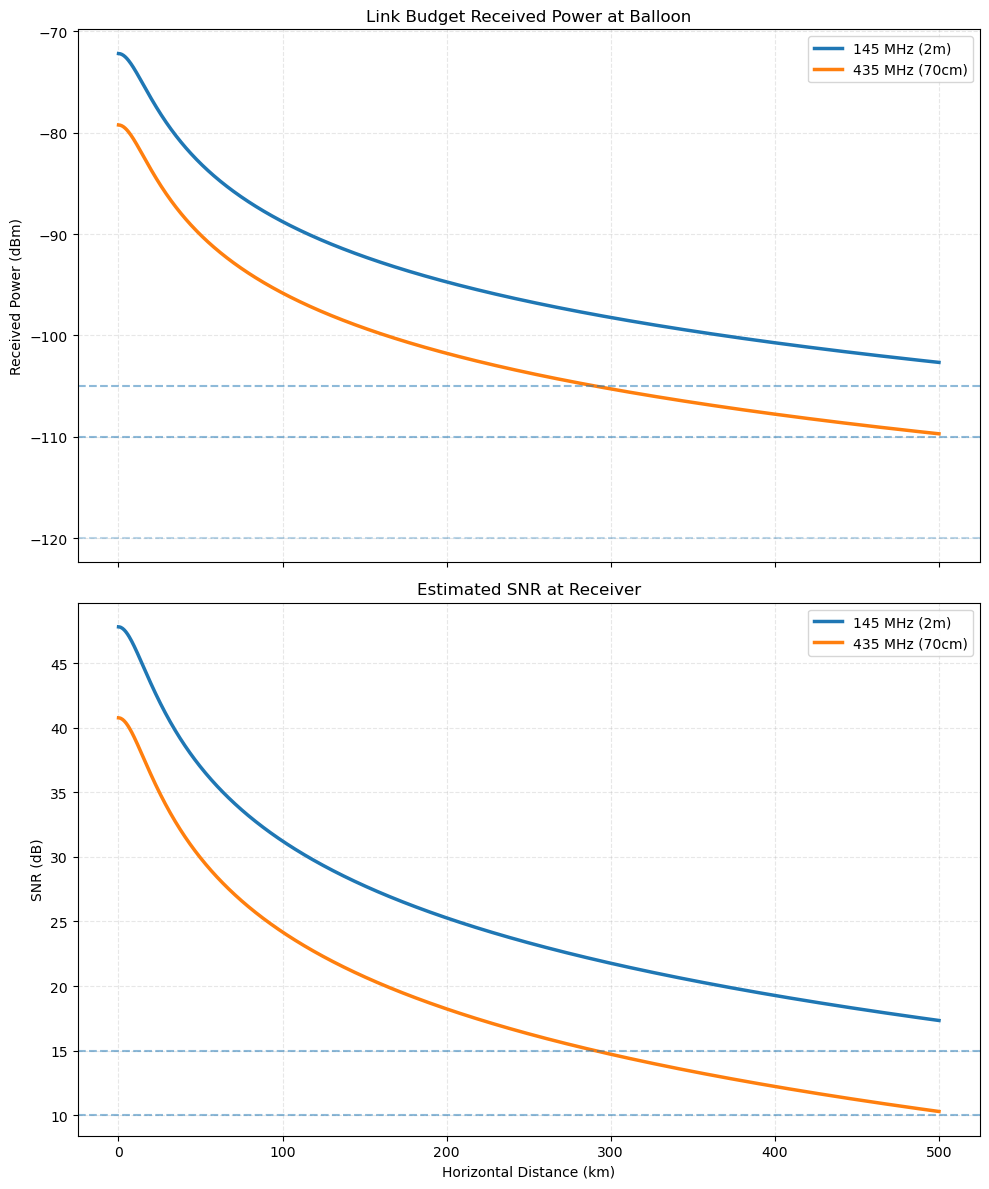

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Free-space path loss
def calculate_path_loss(distance_km, frequency_mhz):
    return 32.45 + 20 * np.log10(frequency_mhz) + 20 * np.log10(distance_km)

# Link budget
P_tx = 37  # dBm
G_tx = 0   # dBi

G_rx = {
    '145 MHz (2m)': 0.0,
    '435 MHz (70cm)': 2.5
}

noise_floor = -120  # dBm

altitude_km = 15
horizontal_distance_km = np.linspace(0.1, 500, 1000)

frequencies = {
    '145 MHz (2m)': 145,
    '435 MHz (70cm)': 435
}

fig, (ax2, ax3) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

for label, freq in frequencies.items():

    slant_range = np.sqrt(horizontal_distance_km**2 + altitude_km**2)
    path_loss = calculate_path_loss(slant_range, freq)

    polarization_loss = 10  # dB (flat loss)

    # Received power
    Prx = P_tx + G_tx + G_rx[label] - path_loss - polarization_loss

    # SNR
    snr = Prx - noise_floor

    # Plot received power
    ax2.plot(horizontal_distance_km, Prx, linewidth=2.5, label=label)

    # Plot SNR
    ax3.plot(horizontal_distance_km, snr, linewidth=2.5, label=label)

# --- Plot 2: Received Power ---
ax2.set_ylabel("Received Power (dBm)")
ax2.set_title("Link Budget Received Power at Balloon")
ax2.grid(True, linestyle="--", alpha=0.3)

# reference lines
ax2.axhline(-110, linestyle="--", alpha=0.5)  # APRS
ax2.axhline(-105, linestyle="--", alpha=0.5)  # FM voice
ax2.axhline(-120, linestyle="--", alpha=0.3)  # noise floor

ax2.legend()

# --- Plot 3: SNR ---
ax3.set_xlabel("Horizontal Distance (km)")
ax3.set_ylabel("SNR (dB)")
ax3.set_title("Estimated SNR at Receiver")
ax3.grid(True, linestyle="--", alpha=0.3)

ax3.axhline(10, linestyle="--", alpha=0.5)  # APRS threshold
ax3.axhline(15, linestyle="--", alpha=0.5)  # FM voice threshold

ax3.legend()

plt.tight_layout()
plt.show()

From this data we can conclude that for APRS, this balloon with even a handheld with a low gain antenna should be able to use both bands to uplink through the entire horizontal range with a lower marign on 70cm especially near the edge of the range. We also see that both bands have a very strong SNR when directly overhead. With a command link with something like a 3el yagi producing 7.1dBi of gain over the simulated whip antenna, either band could be utilized with a good margin for decodability for commands.

### 2.2 Downlink Requirements

For the Uplink, a few parameters we will be using:

#### Transmitter Power : 27 dBm (0.5W) - DRA818
#### Transmit Antenna  : 0 dBi - Quarter Wave Whip antenna on Balloon for 2m
#### Transmit Antenna  : 2.5 dBi Dipole on Balloon for 70cm

#### Average Radio Recieving Performance : ~ -115dBm suburban noise floor
#### Recieving Antenna : 0dBi Quarter Wave Whip Antenna

#### Path Loss
We will be using the estimate of 250km of horizontal distance and 15km of vertical altitude to assume the most average station location case in reference to the balloon

2m Path Loss : 123.64 dB

70cm Path Loss : 133.1 dB

#### Mode-Specific SNR Requirements
These estimates are rough based on links for satellites for SNR needed for a positive packet decode and a good signal for FM voice.

FM Voice : 15dB SNR for readable voice

1200 Baud APRS Packet Deocde : 10dB SNR for consistency in decoding

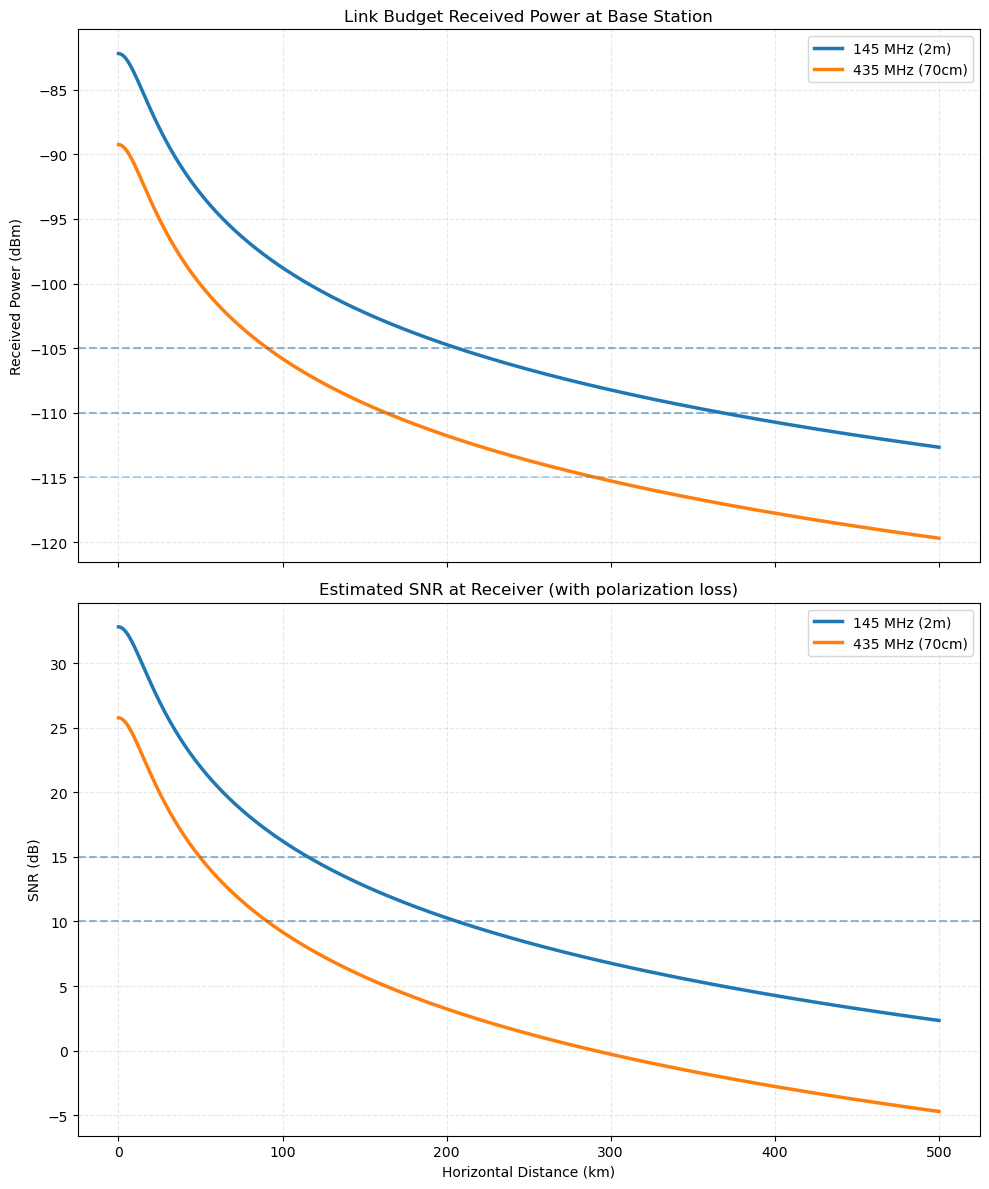

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Free-space path loss
def calculate_path_loss(distance_km, frequency_mhz):
    return 32.45 + 20 * np.log10(frequency_mhz) + 20 * np.log10(distance_km)

# Link parameters
P_tx = 27  # dBm
G_rx = 0   # dBi (ground whip)

G_tx = {
    '145 MHz (2m)': 0.0,
    '435 MHz (70cm)': 2.5
}

noise_floor = -115  # dBm
polarization_loss = 10  # dB

altitude_km = 15
horizontal_distance_km = np.linspace(0.1, 500, 1000)

frequencies = {
    '145 MHz (2m)': 145,
    '435 MHz (70cm)': 435
}

# Plot Setup
fig, (ax2, ax3) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)


# Simulation loop
for label, freq in frequencies.items():

    slant_range = np.sqrt(horizontal_distance_km**2 + altitude_km**2)
    path_loss = calculate_path_loss(slant_range, freq)

    tx_gain = G_tx[label]

    # Received power
    Prx = P_tx + tx_gain + G_rx - path_loss - polarization_loss

    # SNR
    snr = Prx - noise_floor

    # Plot received power
    ax2.plot(horizontal_distance_km, Prx, linewidth=2.5, label=label)

    # Plot SNR
    ax3.plot(horizontal_distance_km, snr, linewidth=2.5, label=label)

# Received Power Plot
ax2.set_ylabel("Received Power (dBm)")
ax2.set_title("Link Budget Received Power at Base Station")
ax2.grid(True, linestyle="--", alpha=0.3)

ax2.axhline(-110, linestyle="--", alpha=0.5)  # APRS
ax2.axhline(-105, linestyle="--", alpha=0.5)  # FM voice
ax2.axhline(-115, linestyle="--", alpha=0.3)  # noise floor

ax2.legend()


# SNR Plot
ax3.set_xlabel("Horizontal Distance (km)")
ax3.set_ylabel("SNR (dB)")
ax3.set_title("Estimated SNR at Receiver (with polarization loss)")
ax3.grid(True, linestyle="--", alpha=0.3)

ax3.axhline(10, linestyle="--", alpha=0.5)  # APRS threshold
ax3.axhline(15, linestyle="--", alpha=0.5)  # FM voice threshold

ax3.legend()

plt.tight_layout()
plt.show()

A note from this is the unfortunate case that the RX will be more "sensitive" than the TX station for the balloon, which makes Crossband-repeater or digipeating modes difficult, as the satellite may recieve a station but not have enough power to make a mutual link equal. It does also mean that with a station wanting to work a contact on this portable station would need far more recieve performance than transmit performance. This also gives a reasonable range for igates to recieve this balloon, where roughly 200km having enough link budget to give consistent decodes from the satellites beacons.

This can also inform our beacon rate, as the necessary beacon rate should be where a new igate could recieve it, to prevent over-beaconing over areas that do not have an igate, or one that can recieve the balloon. We take this and can utilize the previously estimated velocity to note that beaconing could reasonably be done every half hour or so at high movement speeds and potentially every hour or even two hours at low travel speeds without any concern over not having oppertunities to be recieved on the ground.


## 3. Conclusion

The DRA818 Module provides enough output power to function as a crossband repeater with little entry requirements when on the balloon module. Additionally- it seems that 2m provides a recieve experience that goes much further, so for a crossband repeater it may be wise to do a u/V mode so that the burden of power output is on the transmitting station instead of the balloon. It also would be acceptable to have either 2m or 70cm for the command link, as both provide a high margin even with an omnidirectional antenna. These results are likely much more difficult than reality, as the 10dB of cross-polarization could be too high, or mitigated with a circularly polarized antenna, and likely users will have something like a GP or other large base staiton antenna that would provide more gain compared to the 0dBi in the simulation.

These results also show that the command link does not likely need a high power output or large antennas, but just a consistent smaller array. This also means other operators are more likely to have a setup that could reasonably become a trusted command station for the balloon activations.

For the Digipeater mode, V/V is the most wise mode for disaster recovery effort assisting, as it would give the greatest margins on both sides. Potentially as well this could be added to the APRS network temporarily as a digipeater, which would have a very high recieve radius, but low TX radius, which is okay if enabled as a WIDE2 node in an area of large infrastructure failure.